In [3]:
%pip install autograd

  Obtaining dependency information for autograd from https://files.pythonhosted.org/packages/84/ea/e16f0c423f7d83cf8b79cae9452040fb7b2e020c7439a167ee7c317de448/autograd-1.8.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/51.5 kB ? eta -:--:--
   --------------- ------------------------ 20.5/51.5 kB 320.0 kB/s eta 0:00:01
   --------------- ------------------------ 20.5/51.5 kB 320.0 kB/s eta 0:00:01
   ---------------------------------------  51.2/51.5 kB 327.7 kB/s eta 0:00:01
   ---------------------------------------- 51.5/51.5 kB 262.7 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from autograd import jacobian
import autograd.numpy as anp


In [26]:
Q = np.diag([1.0, 1.0])

def f(x):
    x = anp.asarray(x)
    return 0.5 * (x - anp.array([1.0, 0.0])).T @ Q @ (x - anp.array([1.0, 0.0]))

def grad_f(x):
    return Q @ (x - np.array([1.0, 0.0]))

def hess_f(x):
    return Q

def c(x):
    return x[0]**2 + 2*x[0] - x[1]

def dc(x):
    return np.array([2*x[0] + 2, -1.0])


(2,)
2Grad L : [[1. 0.]
 [0. 1.]]
[[ 1.  0.  0.]
 [ 0.  1. -1.]
 [ 0. -1.  0.]]


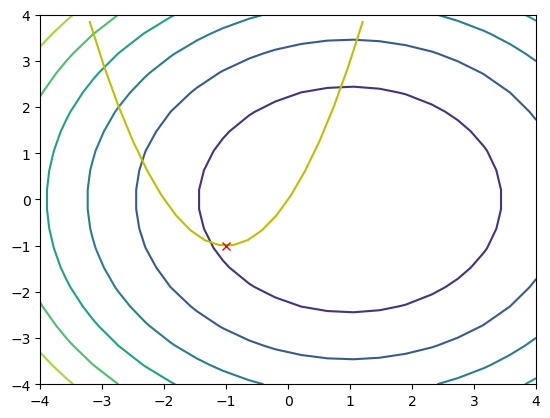

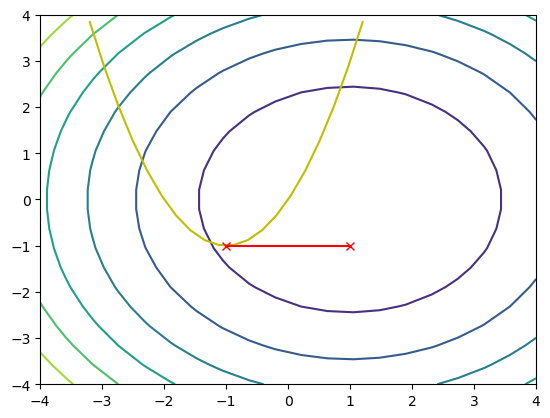

In [38]:
def plot_landscape():
    Nsamp = 20
    xs = np.linspace(-4, 4, Nsamp)
    ys = np.linspace(-4, 4, Nsamp)

    X, Y = np.meshgrid(xs, ys)
    Z = np.zeros_like(X)

    for i in range(Nsamp):
        for j in range(Nsamp):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))

    plt.contour(X, Y, Z)

    xc = np.linspace(-3.2, 1.2, Nsamp)
    plt.plot(xc, xc**2 + 2*xc, "y")

def newton_step(x0, lam0):
    # Hessian of Lagrangian
    def lag_dc(x):
        return dc(x).reshape(1, -1) * lam0

    H = hess_f(x0) + jacobian(lag_dc)(x0).squeeze()
    
    print(dc(x0).shape)
    
    C = dc(x0).reshape(1, -1)

    print("2Grad L :" , H)
    
    KKT = np.block([
        [H, C.T],
        [C, np.zeros((1, 1))]
    ])
    
    print(KKT)

    rhs = np.concatenate([
        -grad_f(x0) - C.T.flatten() * lam0,
        np.array([-c(x0)])
    ])

    dz = np.linalg.solve(KKT, rhs)

    dx = dz[:2]
    dlam = dz[2]

    return x0 + dx, lam0 + dlam

xguess = np.array([-1.0, -1.0])
lamguess = 0.0

plt.figure()
plot_landscape()
plt.plot(xguess[0], xguess[1], "rx")

xnew, lamnew = newton_step(xguess, lamguess)

plt.figure()
plot_landscape()
plt.plot([xguess[0], xnew[0]], [xguess[1], xnew[1]], "rx-")
plt.show()


(2,)
[[ 1.  0.  0.]
 [ 0.  1. -1.]
 [ 0. -1.  0.]]


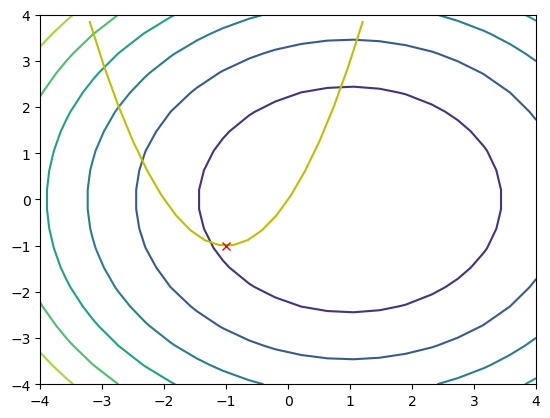

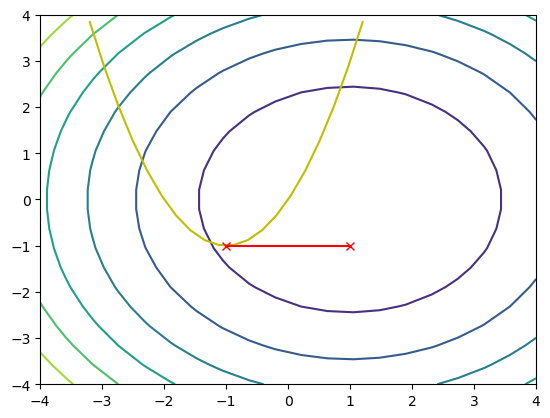

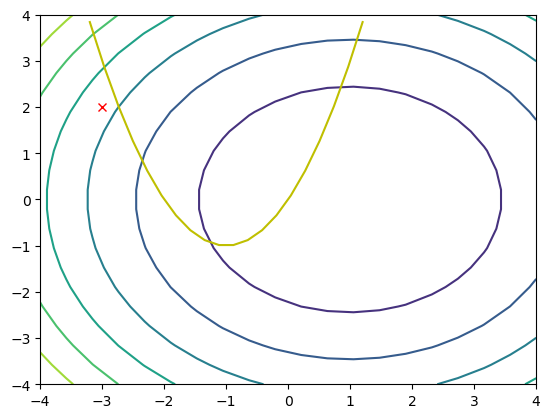

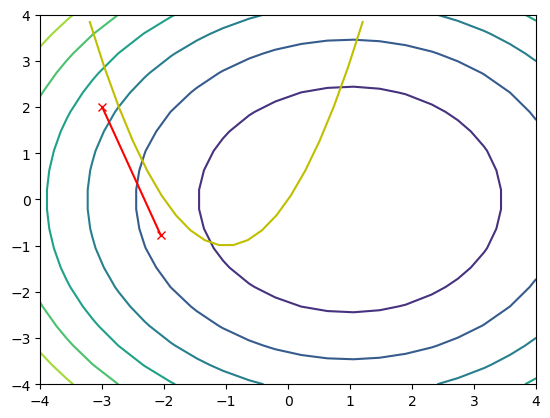

In [51]:
def gauss_newton_step(x0, lam0):
    H = hess_f(x0)
    C = dc(x0).reshape(1, -1)

    KKT = np.block([
        [H, C.T],
        [C, np.zeros((1, 1))]
    ])

    rhs = np.concatenate([
        -grad_f(x0) - C.T.flatten() * lam0,
        np.array([-c(x0)])
    ])

    dz = np.linalg.solve(KKT, rhs)

    dx = dz[:2]
    dlam = dz[2]

    return x0 + dx, lam0 + dlam


xguess = np.array([-3.0, 2.0])
lamguess = 0.0

plt.figure()
plot_landscape()
plt.plot(xguess[0], xguess[1], "rx")

xnew, lamnew = gauss_newton_step(xguess, lamguess)

plt.figure()
plot_landscape()
plt.plot([xguess[0], xnew[0]], [xguess[1], xnew[1]], "rx-")
plt.show()


0.35809431568394995


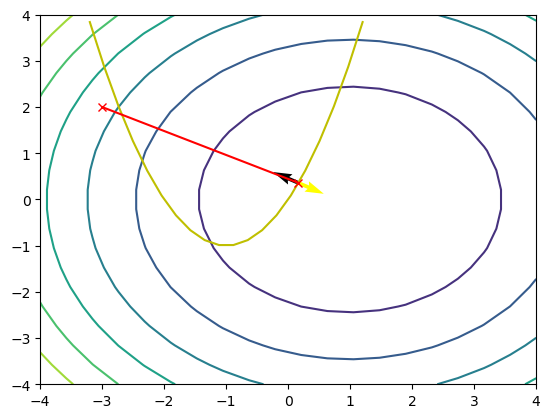

In [63]:
xnew, lamnew = gauss_newton_step(xnew, lamnew)

plt.figure()
plot_landscape()
plt.plot([xguess[0], xnew[0]], [xguess[1], xnew[1]], "rx-")

# I wanna plot multipliers and gradient
func_gradient = grad_f(xnew)
cons_gradient = dc(xnew)

plt.quiver(xnew[0],xnew[1], func_gradient[0], func_gradient[1], color = 'black')
plt.quiver(xnew[0],xnew[1], cons_gradient[0], cons_gradient[1], color = 'yellow')

print(lamnew)

plt.show()

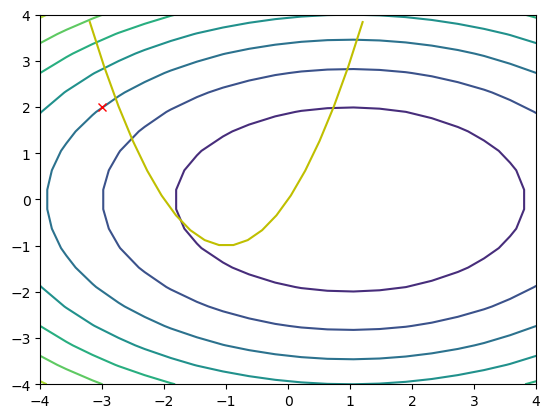

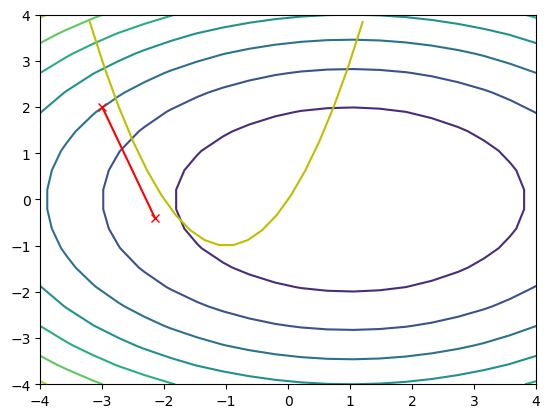